In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Input, Dropout,
    Conv2D, MaxPooling2D, Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint

In [3]:
# Load MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
# Display dataset shapes
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)
print("Sample training label:", train_labels[0])
print("Sample training image shape:", train_images[0].shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Sample training label: 5
Sample training image shape: (28, 28)


In [5]:
labels = np.unique(train_labels)
print("labels are:", labels)

labels are: [0 1 2 3 4 5 6 7 8 9]


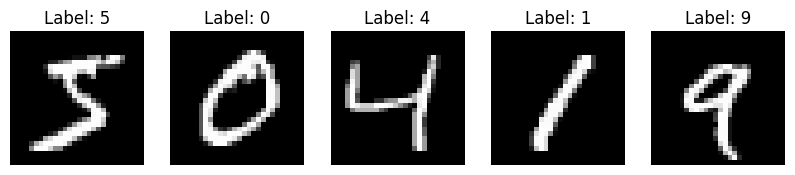

In [6]:
# Function to plot sample images
def plot_sample_images(images, labels, num_samples=5):
    plt.figure(figsize=(10, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.show()

plot_sample_images(train_images, train_labels)

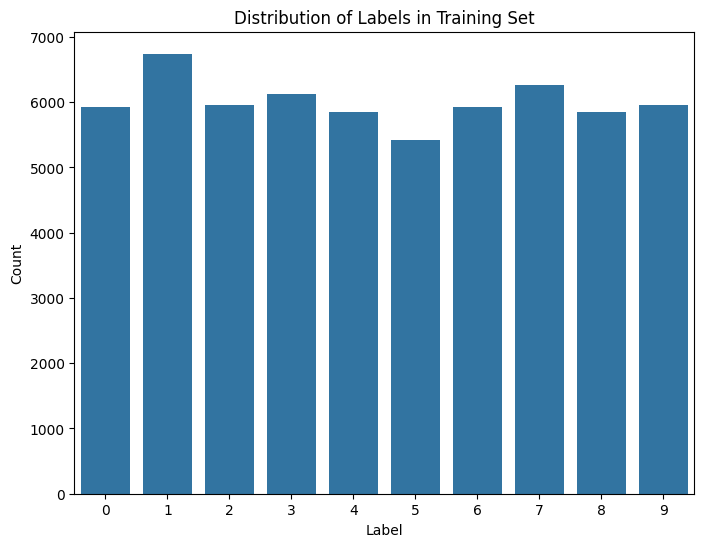

In [7]:
# Label distribution plot
plt.figure(figsize=(8, 6))
sns.countplot(x=train_labels.tolist())
plt.title("Distribution of Labels in Training Set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

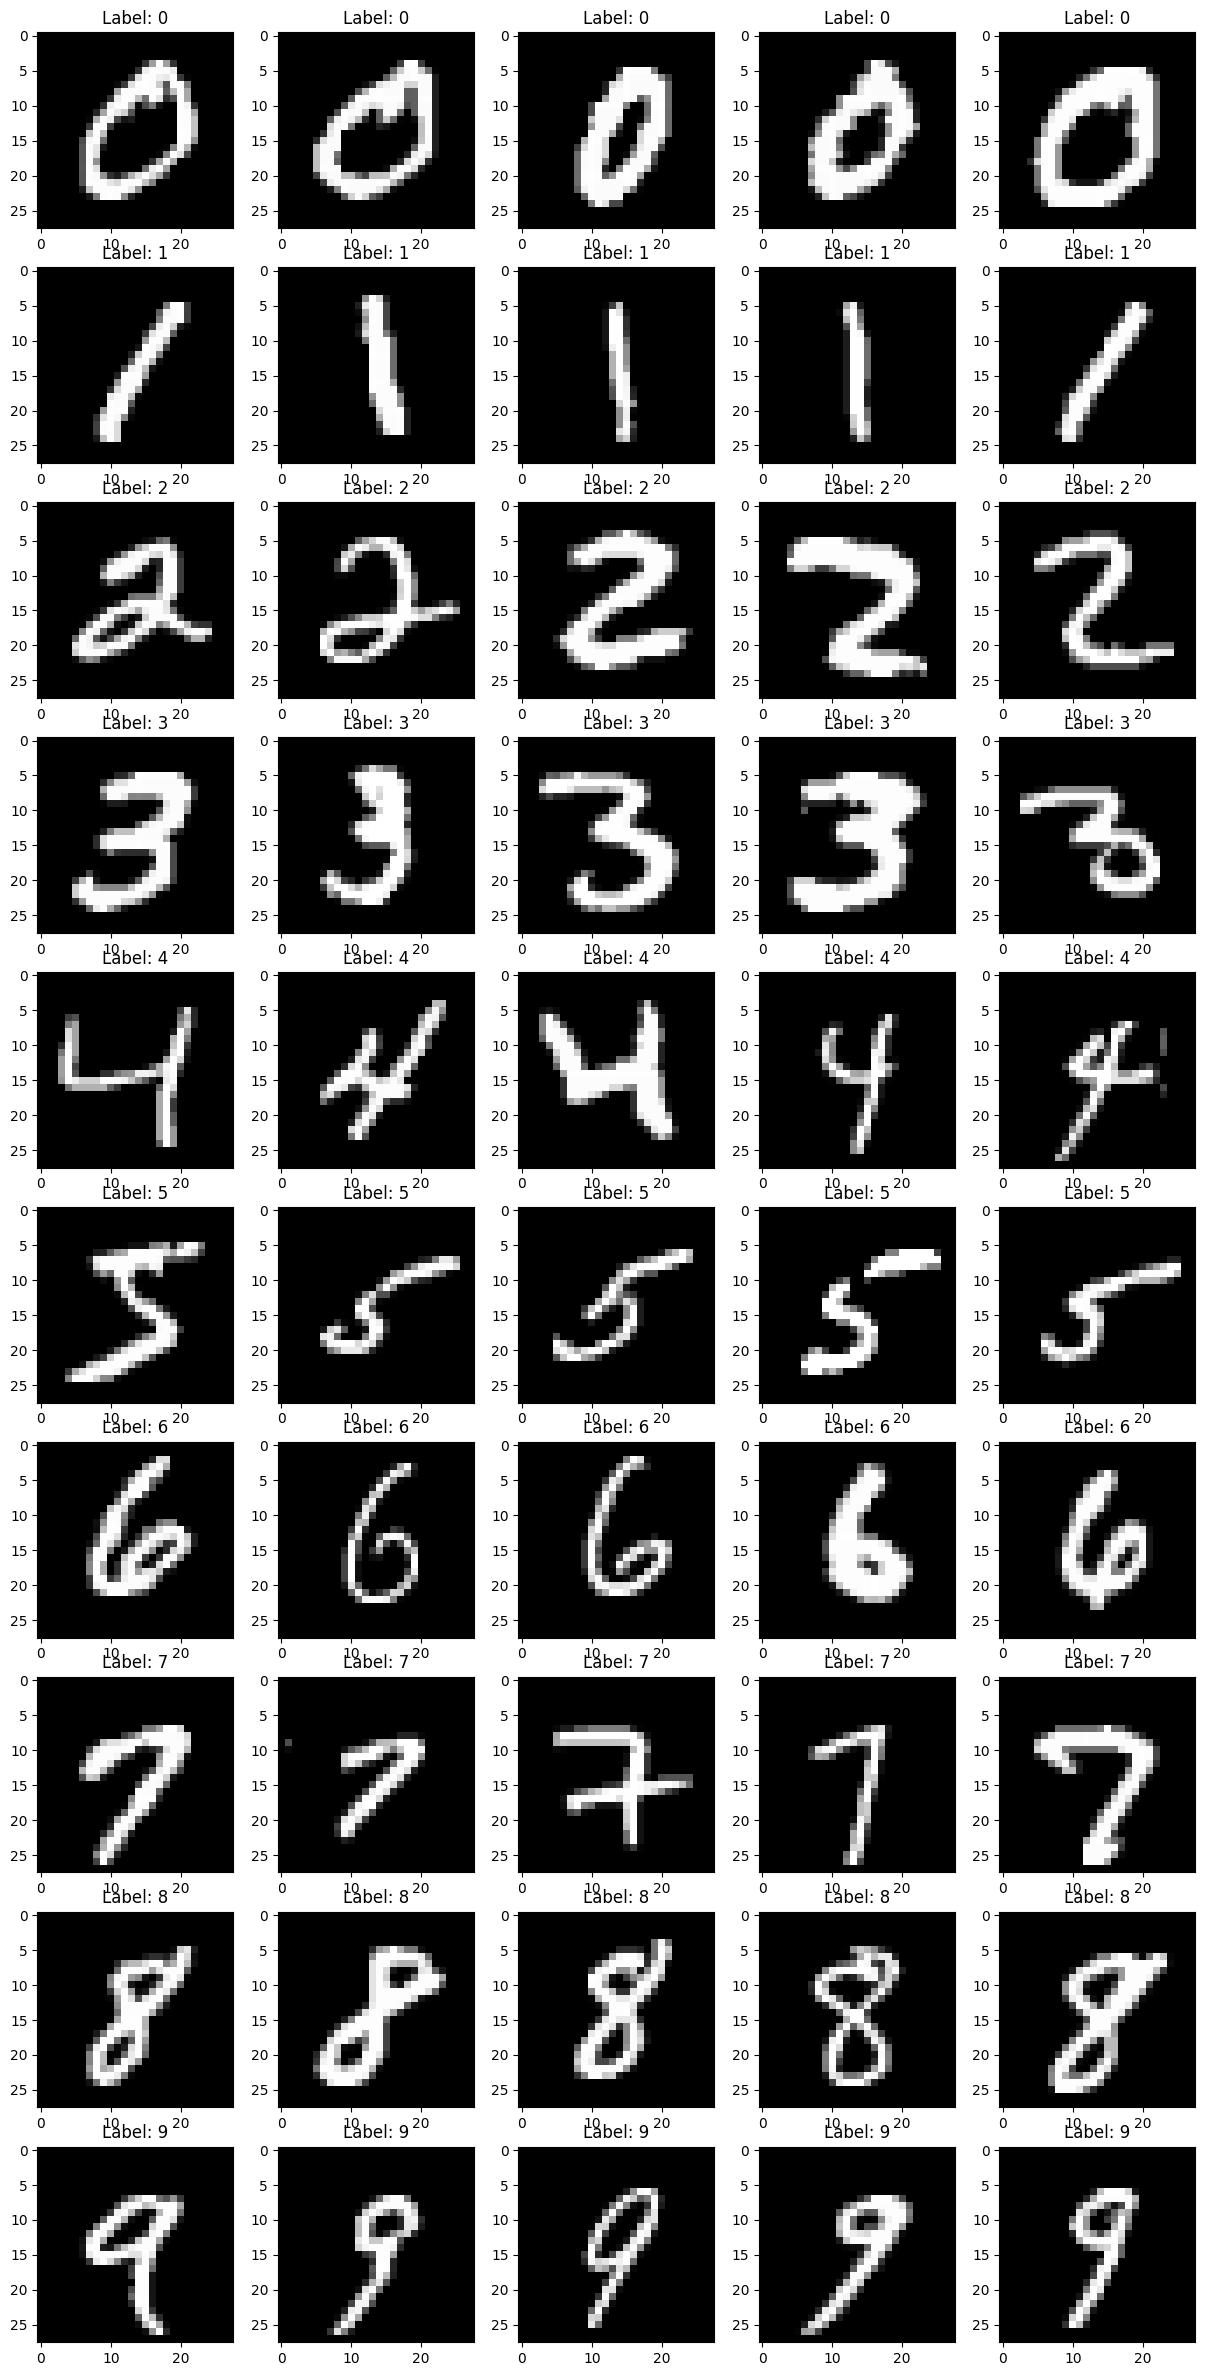

In [8]:
# Function to plot images by class
def plot_images_by_class(images, labels, num_classes=10, num_samples=5):
    plt.figure(figsize=(15, num_classes * 3))
    for label in range(num_classes):
        class_images = images[np.where(labels == label)]
        for i in range(num_samples):
            plt.subplot(num_classes, num_samples, label * num_samples + i + 1)
            plt.imshow(class_images[i], cmap='gray')
            plt.title(f"Label: {label}")
    plt.show()

plot_images_by_class(train_images, train_labels)

In [9]:
# Normalize images

train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# One-hot encode labels
train_labels_categorical = to_categorical(train_labels)
test_labels_categorical = to_categorical(test_labels)

Model 1: Long Short-Term Memory

In [10]:
# Build LSTM model
model_lstm = Sequential([
    Input(shape=(28, 28)),
    LSTM(128, return_sequences=True),
    Dropout(0.1),
    LSTM(64),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy',
                   metrics=['accuracy'])
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 128)        │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,442 (509.54 KB)

 Trainable params: 130,442 (509.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
callbacks = [ModelCheckpoint('digit_recognition_model.keras', verbose=1, save_best_only=True)]

In [12]:
history_lstm = model_lstm.fit(train_images, train_labels_categorical,
                              epochs=15, batch_size=128,
                              validation_data=(test_images, test_labels_categorical), callbacks=callbacks)

Epoch 1/15
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6703 - loss: 0.9719
Epoch 1: val_loss improved from inf to 0.15388, saving model to digit_recognition_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6714 - loss: 0.9690 - val_accuracy: 0.9534 - val_loss: 0.1539
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9517 - loss: 0.1615
Epoch 2: val_loss improved from 0.15388 to 0.10281, saving model to digit_recognition_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9517 - loss: 0.1614 - val_accuracy: 0.9662 - val_loss: 0.1028
Epoch 3/15
464/469 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9701 - loss: 0.1032
Epoch 3: val_loss improved from 0.10281 to 0.07396, saving model to digit_recognition_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9701 - loss: 0.1031 - val_accuracy: 0.9760 - val_loss: 0.0740
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9778 - loss: 0.0727
Epoch 4: val_

In [13]:
# Evaluate LSTM model
test_loss, test_accuracy = model_lstm.evaluate(test_images, test_labels_categorical)
print('Test accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9829 - loss: 0.0636
Test accuracy: 0.9861999750137329


In [14]:
# Training history visualization
def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(title + ' Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(title + ' Loss')
    plt.show()

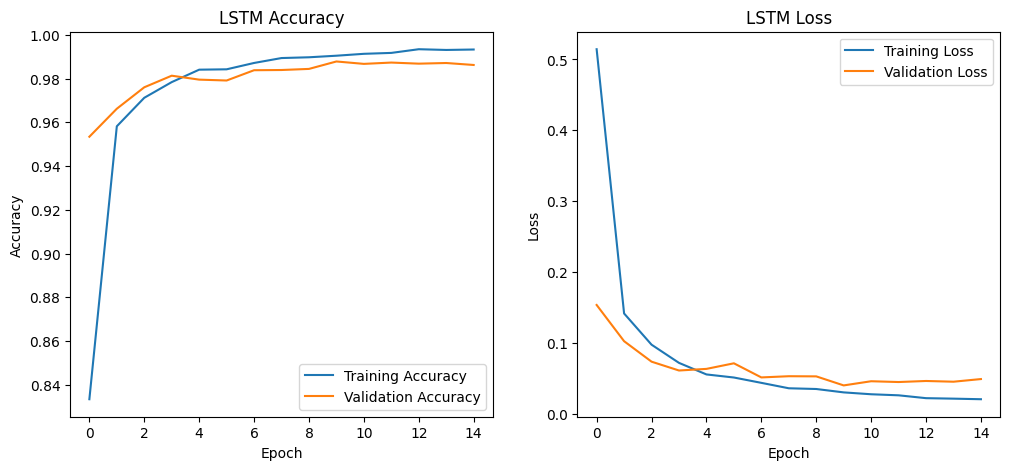

In [15]:
plot_training_history(history_lstm, "LSTM")

In [16]:
# Predict on a sample image

def predict_sample(model, sample_image, title):
    sample_image = np.expand_dims(sample_image, axis=0)
    prediction = model.predict(sample_image)
    predicted_class = np.argmax(prediction)

    plt.imshow(sample_image[0], cmap='gray')
    plt.title(f"Predicted Class ({title}): {predicted_class}")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


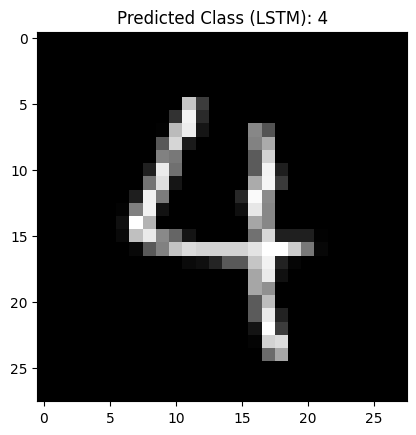

In [17]:
predict_sample(model_lstm, test_images[24], "LSTM")

Model 2: Convolutional Neural Network

In [18]:
train_images_cnn = train_images.reshape(-1, 28, 28, 1)
test_images_cnn = test_images.reshape(-1, 28, 28, 1)

In [19]:
model_cnn = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_cnn.compile(optimizer= 'adam', loss= 'categorical_crossentropy', metrics= ['accuracy'])
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train CNN
callbacks = [ModelCheckpoint("cnn_digit_model.keras", save_best_only=True, verbose=1)]

history_cnn = model_cnn.fit(
    train_images_cnn,
    train_labels_categorical,
    epochs=15,
    batch_size=128,
    validation_data=(test_images_cnn, test_labels_categorical),
    callbacks=callbacks
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7804 - loss: 0.6662
Epoch 1: val_loss improved from inf to 0.06912, saving model to cnn_digit_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.7806 - loss: 0.6655 - val_accuracy: 0.9767 - val_loss: 0.0691
Epoch 2/15
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9642 - loss: 0.1227
Epoch 2: val_loss improved from 0.06912 to 0.04189, saving model to cnn_digit_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9642 - loss: 0.1226 - val_accuracy: 0.9848 - val_loss: 0.0419
Epoch 3/15
461/469 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9749 - loss: 0.0835
Epoch 3: val_loss improved from 0.04189 to 0.03754, saving model to cnn_digit_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9749 - loss: 0.0835 - val_accuracy: 0.9861 - val_loss: 0.0375
Epoch 4/15
458/469 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9773 - loss: 0.0756
Epoch 4: val_loss improved from 0.03

In [21]:
# Evaluate CNN model
test_loss, test_accuracy = model_cnn.evaluate(test_images_cnn, test_labels_categorical)
print('CNN Test accuracy:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9915 - loss: 0.0237
CNN Test accuracy: 0.9932000041007996


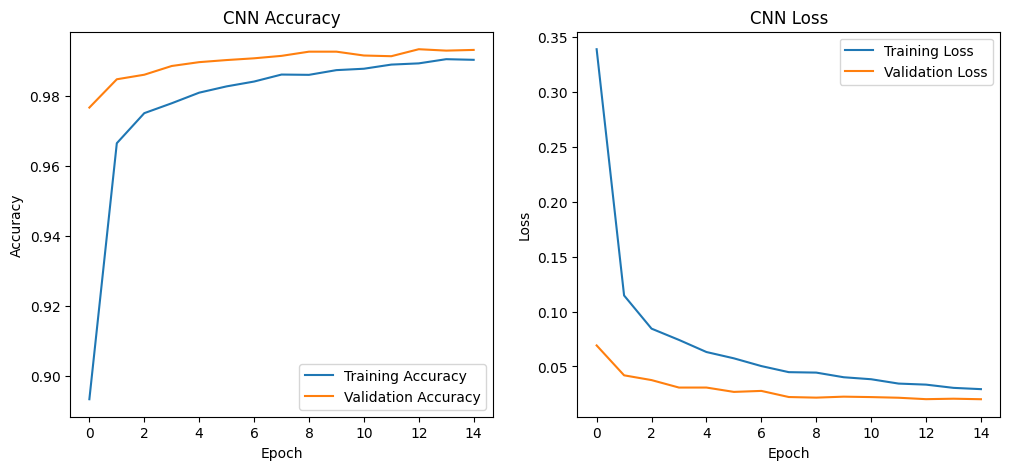

In [22]:
plot_training_history(history_cnn, "CNN")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


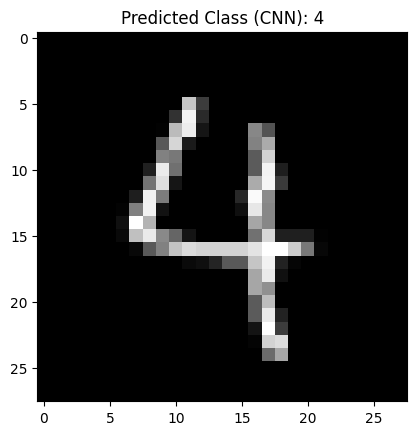

In [23]:
predict_sample(model_cnn, test_images_cnn[24], "CNN")